# 지도학습_다중회귀분석_고객별연간지출액예측

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [4]:
data = pd.read_csv('./data/ecommerce.csv')

In [5]:
data

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [7]:
data.isna().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [8]:
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


<Axes: >

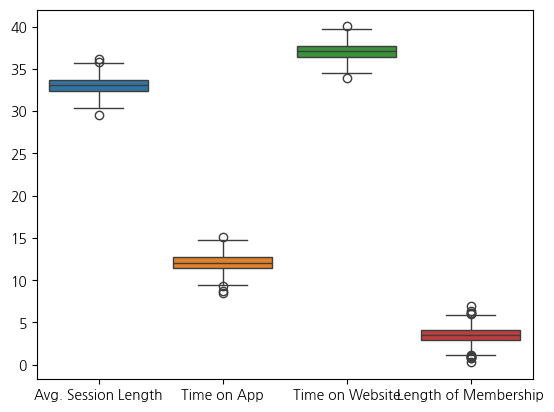

In [9]:
# 종속변수인 Yearly Amount Spent 제외하고 ERD 진행
sns.boxplot(data.drop('Yearly Amount Spent', axis=1))

In [10]:
# 종속변수에 관계없어보이는 컬럼 삭제 (범주형)
data = data.drop((['Email', 'Address', 'Avatar']), axis=1)

In [11]:
cols = data.columns[:-1]

============================== Avg. Session Length ==============================


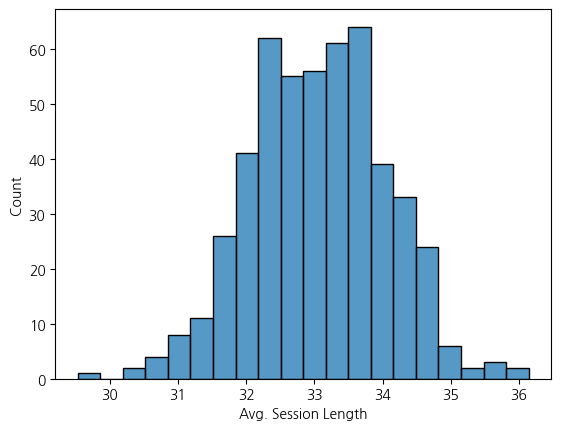

============================== Time on App ==============================


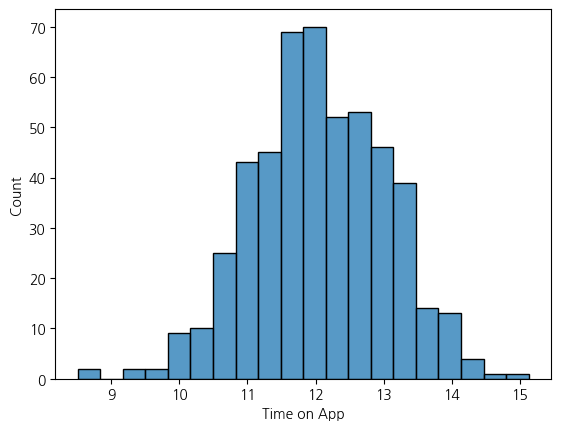

============================== Time on Website ==============================


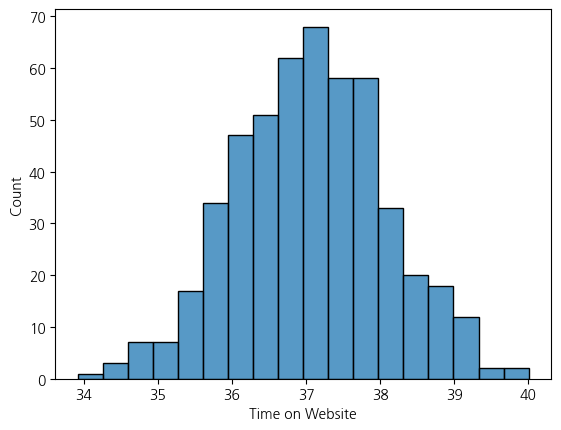

============================== Length of Membership ==============================


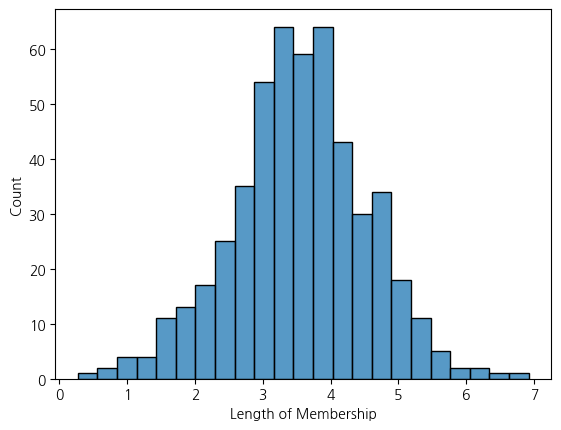

In [12]:
# 자료값의 분포 확인
for col in cols:
    print("="*30,col,"="*30)
    sns.histplot(data[col])
    plt.show()

In [13]:
# 컬럼의 상관관계 분석
data.corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


<Axes: >

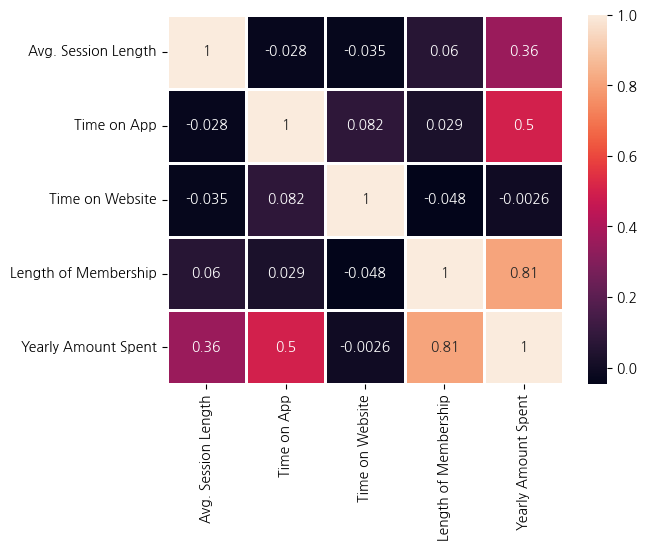

In [14]:
# 상관관계 시각화
sns.heatmap(data.corr(), annot=True, linewidth=1)

## 데이터 홀드아웃, 스케일링, 분석

In [15]:
X = data.drop('Yearly Amount Spent', axis=1)
y = data['Yearly Amount Spent']

### 데이터 홀드아웃

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

### 스케일링
* Standard Scaler로 독립변수의 단위 조정

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
ss = StandardScaler()
ss.fit(X_train)
ss_X_train = ss.transform(X_train)
ss_X_test = ss.transform(X_test)

In [20]:
# 스케일링한 데이터를 다시 훈련세트, 검증세트에 할당
X_train = pd.DataFrame(ss_X_train, columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(ss_X_test, columns=X.columns, index=X_test.index)

# 다중 선형 회귀분석

In [21]:
# statsmodels의 python 문법
import statsmodels.api as sm

In [22]:
# 상수항 추가
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [23]:
lr = sm.OLS(y_train, X_train_const).fit()
print(lr.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     6676.
Date:                 Mon, 19 May 2025   Prob (F-statistic):               0.00
Time:                         13:30:35   Log-Likelihood:                -1480.1
No. Observations:                  400   AIC:                             2970.
Df Residuals:                      395   BIC:                             2990.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

* y = (25.2504 * Avg. Session Length) + (38.7035 * Time on App) + (0.3155 * Time on Website) + (63.5432 * Length of Membership) + 501.9922
* adj-R-square: 0.985: 98.5%의 설명력을 가지고 있다.
* p-value: 0.05미만

# 회귀분석의 지표

* MSE(mean_squared_error): 평균제곱오차 - 회귀선과 데이터간의 오차
* RMSE(root mean_squared_error): 루트평균제곱오차 - 단위를 다시 원위치 시킨 오차

In [24]:
from sklearn.metrics import mean_squared_error

In [25]:
# 회귀분석모델로 예측하기
pred = lr.predict(X_test_const)

In [26]:
print("mean_squared_error: ", mean_squared_error(y_test, pred))
print("root_mean_squared_error: ", np.sqrt(mean_squared_error(y_test, pred)))

mean_squared_error:  109.86374118394059
root_mean_squared_error:  10.481590584636503


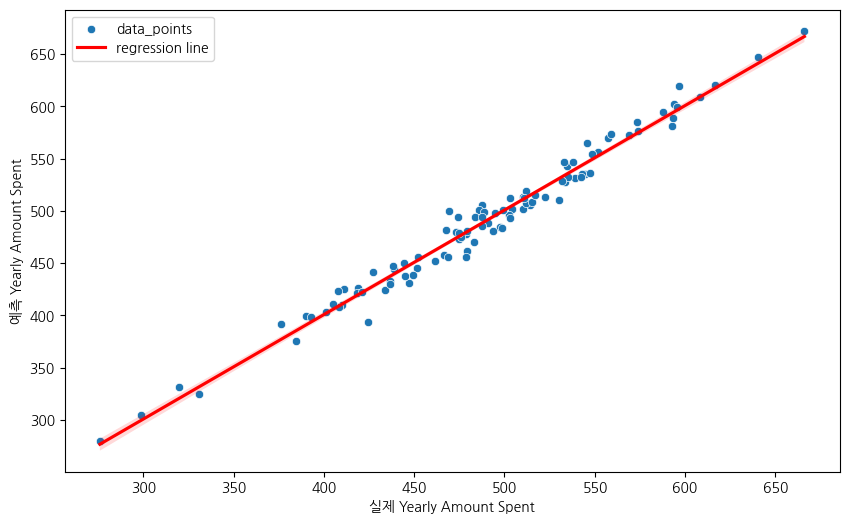

In [27]:
# 산점도와 회귀선 그리기
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=pred, label='data_points')
sns.regplot(x=y_test, y=pred, scatter=False, label='regression line', color='red')
plt.xlabel("실제 Yearly Amount Spent")
plt.ylabel("예측 Yearly Amount Spent")
plt.legend()
plt.show()

# R 문법으로 statsmodels 회귀분석하기

In [28]:
# import statsmodels.api as sm - python 방식
from statsmodels.formula.api import ols

In [29]:
train_data = pd.concat([X_train,y_train], axis=1)
test_data = pd.concat([X_test,y_test], axis=1)

In [30]:
train_data.columns = ['AvgSessionLength', 'TimeonApp', 'TimeonWebsite',
       'LengthofMembership', 'YearlyAmountSpent']
test_data.columns = ['AvgSessionLength', 'TimeonApp', 'TimeonWebsite',
       'LengthofMembership', 'YearlyAmountSpent']

1. 종속변수 ~ 독립변수1 + 독립변수2 식으로 붙여넣기

In [31]:
model = ols('YearlyAmountSpent ~ AvgSessionLength + TimeonApp + TimeonWebsite + LengthofMembership', data = train_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      YearlyAmountSpent   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     6676.
Date:                Mon, 19 May 2025   Prob (F-statistic):               0.00
Time:                        13:30:35   Log-Likelihood:                -1480.1
No. Observations:                 400   AIC:                             2970.
Df Residuals:                     395   BIC:                             2990.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            501.9922      0

2. join 함수를 통해 위 문장으로 구현

In [32]:
model = ols('YearlyAmountSpent ~ ' + "+".join(train_data.columns[:-1]) , data=train_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      YearlyAmountSpent   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     6676.
Date:                Mon, 19 May 2025   Prob (F-statistic):               0.00
Time:                        13:30:35   Log-Likelihood:                -1480.1
No. Observations:                 400   AIC:                             2970.
Df Residuals:                     395   BIC:                             2990.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            501.9922      0

# 사이킷런을 이용한 회귀분석

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
X_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,-0.997132,-1.713455,1.991749,-0.130046
73,-0.256010,0.761003,0.010579,0.276169
374,-1.635907,-1.960221,1.006187,0.652866
155,-0.620106,1.402969,0.214506,-0.610417
104,-1.694561,-1.065741,1.036687,-0.135598
...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081
86,0.827716,0.460923,0.129021,-0.874853
75,-1.025263,0.180722,1.682520,-0.435901
438,-0.924682,-2.014653,0.158072,-0.032122


In [35]:
slr = LinearRegression()
slr.fit(X_train, y_train)
pred3 = slr.predict(X_test)
print("mse:  ", mean_squared_error(y_test, pred3))
print("rmse:  ", np.sqrt(mean_squared_error(y_test, pred3)))

mse:   109.86374118394046
rmse:   10.481590584636496


In [36]:
# y절편, 회귀계수, 변수이름
print("y절편: ", slr.intercept_)
print("각 변수의 회귀 계수: ", slr.coef_)
print("각 변수의 이름: ", slr.feature_names_in_)

y절편:  501.9921512124531
각 변수의 회귀 계수:  [25.25038131 38.70350139  0.31546926 63.54321107]
각 변수의 이름:  ['Avg. Session Length' 'Time on App' 'Time on Website'
 'Length of Membership']


In [37]:
model_coef = pd.DataFrame(dict(feature=slr.feature_names_in_, coef=slr.coef_))
model_coef

,feature,coef
0,Avg. Session Length,25.250381
1,Time on App,38.703501
2,Time on Website,0.315469
3,Length of Membership,63.543211


$ R^2 $ 값 출력하기

In [38]:
# 결정계수 -> 설명력
r2 = slr.score(X_test, y_test)
print("r2: ", r2)

r2:  0.9778130629184125
